In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Importing Libraries

In [3]:
# importing all libraries
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score

import wandb

# installing required libraries
import subprocess
import sys

subprocess.run([sys.executable, '-m', 'pip', 'install', 'wandb', '-q'])
!pip install chonkie


print('done installing')

# checking if gpu is available
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('GPU is available:', torch.cuda.get_device_name(0))
else:
    device = torch.device('cpu')
    print('GPU not available, using CPU')

print('pytorch version:', torch.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.9/230.9 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.2/387.2 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 85.3 MB/s eta 0:00:00
done installing
GPU is available: Tesla T4
pytorch version: 2.10.0+cu128


# WANDB LOGIN

In [4]:
# setting up wandb login
# using relogin=True so it doesnt ask for input during kaggle rerun
WANDB_KEY = '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'  

wandb.login(key=WANDB_KEY, relogin=True)
print('wandb login done')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb login done


In [5]:
# Chonkie breaks long texts into smaller chunks
# These chunks are stored in a vector database
# For each question we retrieve the most relevant chunks as context

from chonkie import RecursiveChunker

train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')


# sample text - in our project this would be the training questions
TEXT = train['prompt'].iloc[0] + ' ' + train['A'].iloc[0]

print('initializing wandb')
run0 = wandb.init(
    project = '23f3001514-t22026',
    entity  = '23f3001514-instituition',
    name    = 'chonkie-recursive-chunker',
    config  = {
        'chunking_method' : 'recursive',
        'chunk_size'      : 250,
    }
)

config = wandb.config
c_size = config.chunk_size

# RecursiveChunker splits text recursively
# first tries to split by paragraphs
# then by sentences
# then by words
# until each chunk is under chunk_size
chunker     = RecursiveChunker(chunk_size=c_size)
chunks      = chunker.chunk(TEXT)
chunk_texts = [chunk.text for chunk in chunks]

print('total chunks created:', len(chunk_texts))

wandb.log({
    'num_chunks'       : len(chunk_texts),
    'avg_chunk_length' : sum(len(c) for c in chunk_texts) / len(chunk_texts)
})

# logging chunks as a table in wandb
table = wandb.Table(columns=['chunk_id', 'chunk_text'])
for idx, chunk_text in enumerate(chunk_texts):
    table.add_data(idx, chunk_text)

wandb.log({'chunks': table})
run0.finish()
print('chunking logged to wandb!')

initializing wandb


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


total chunks created: 3


avg_chunk_length,▁
num_chunks,▁
avg_chunk_length,150
num_chunks,3


chunking logged to wandb!


**INSIGHT**:

*Chonkie split the text into 3 chunks of average 150 characters each. Since this is not a training loop — just a single chunking operation — the chart shows one data point. I logged num_chunks and avg_chunk_length to W&B to track how the chunking settings affect the output.*

# EDA

In [20]:

# ============= Loading Datasets ================

train = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')


# ====== shape of train and test dataset ======

print("shape of train and test data")
print('='*40)
print('Train shape : ' , train.shape)
print()
print('Test shape : ' , test.shape)

# ======= data inspection ==========

print('='*40)
print('Train columns:', train.columns.tolist())
print()

# ======= Checking Missing values =======

print('='*40)
print()
print('Train set missing values : ', train.isnull().sum())

# ======= frequency of each options ========

print('='*40)
print('frequency of an option for being correct : '  , train['answer'].value_counts())


shape of train and test data
Train shape :  (2000, 8)

Test shape :  (500, 7)
Train columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']


Train set missing values :  id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64
frequency of an option for being correct :  answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


**INSIGHT**

*The training dataset contains 2,000 questions with answers, while the test dataset contains 500 questions without the answer column for prediction.*

*The training data has 8 columns (id, prompt, five options A–E, and the correct answer), whereas the test data has 7 columns since the target column is missing.*

*No missing values are present in any column, indicating that the dataset is clean and does not require missing value handling before training.*

*The target variable (answer) is slightly imbalanced. Option B appears most frequently as the correct answer, while E appears the least. However, the distribution is still reasonably balanced, so it is suitable for model training without major concerns.*

# Visualization

Answer distribution plot and Question length distribution



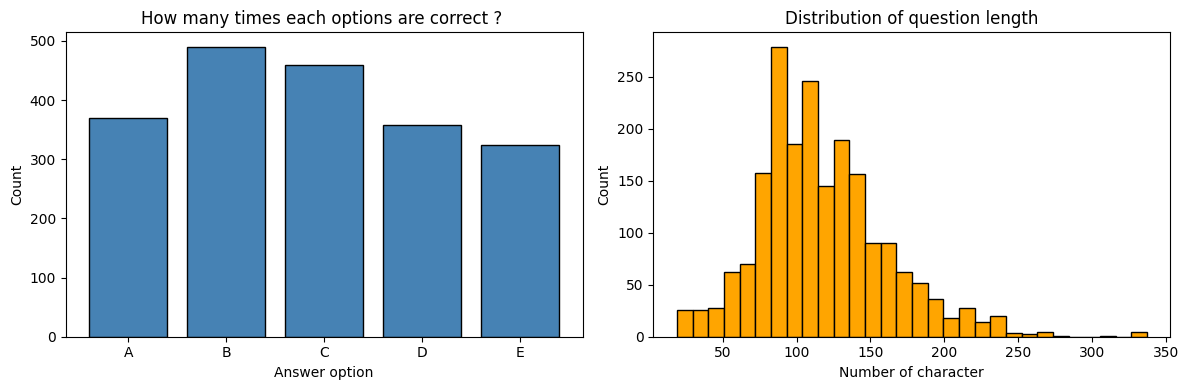

In [25]:
# # EDA - looking at the data visually
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ========== answer distribution plot =============

print('Answer distribution plot and Question length distribution')
print('='*50)
print()
answer_count = train['answer'].value_counts().sort_index()
axes[0].bar(answer_count.index , answer_count.values , color = 'Steelblue' , edgecolor = 'Black')
axes[0].set_title('How many times each options are correct ? ')
axes[0].set_xlabel('Answer option')
axes[0].set_ylabel('Count')

# =========== Question length distribution ===============

train['prompt_length'] = train['prompt'].apply(lambda x :  len(str(x)))
axes[1].hist(train['prompt_length'] , bins = 30 , color = 'Orange' ,  edgecolor = 'Black')
axes[1].set_title('Distribution of question length')
axes[1].set_xlabel('Number of character')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('/kaggle/working/eda_plots.png', dpi=100)
plt.show()


**INSIGHT**

**The answer distribution shows that all five options (A–E) appear as the correct answer, although Option B is the most frequent and Option E is the least frequent. This indicates only a slight class imbalance, with no single option dominating the dataset.
The question length distribution is approximately bell-shaped, with most questions containing 60–250 characters. This suggests that the majority of questions have a consistent length.
Only a small number of questions are unusually short or very long, indicating the presence of a few outliers, but they are not significant enough to affect the overall dataset quality.**